# **Dokumentation BookStoreDB**  
Detta dokument innehåller en sammanställning av design och implementation av databasen BookStoreDB,  
samt motiveringar till de val som gjorts under arbetets gång.   
  
Dokumentet beskriver: 
- Tabeller
- Relationer och Nycklar
- normalisering
- stored procedures
- Datatyper och Demodata
- vyer
- Python-integrationen
- integritetsvillkor   

### **Tabeller**

#### Obligatoriska entiteter
- Authors
- Books
- Stores
- Inventory  

#### Egna entiteter 
- Publishers
- Customers
- Orders
- OrderRows  
  
Fyra extra entiter valdes utifrån att bokhandeln ska kunna hantera försäljning.  
   
"OrderRows" fungerar delvis som en koppling mellan Orders och Books, men ses främst som en transaktions-/händelsetabell   
eftersom den innehåller egen affärsdata som "Quantity" och "UnitPrice". 

#### Junction table
- BookAuthors

"BookAuthors" används för att skapa many-to-many mellan "Authors" och "Books". Tabellen består av kolumnerna ISBN13 och AuthorID,  
där båda är foreign keys och tillsammans bildar en sammansatt primary key.

### **Relationer och Nycklar**

Alla tabeller har primary keys. Relationerna mellan tabellerna styrs med foreign keys  
så att en foreign key inte kan peka på en rad som inte finns.
  
#### ER-diagram  
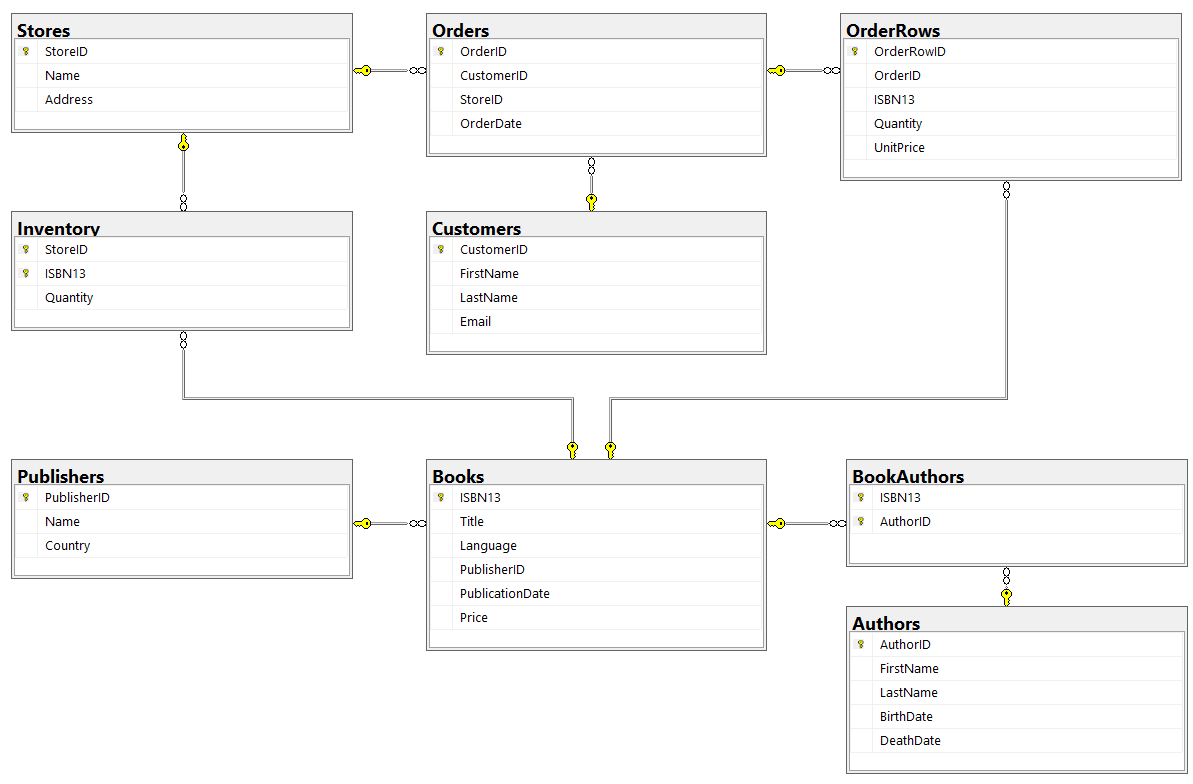

### **Normalisering**

Information lagras bara på ett ställe:
- författarinformation finns i Authors
- bokinformation finns i Books
- kundinformation finns i Customers
- lagerantal finns i Inventory
- orderinnehåll finns i OrderRows

Detta minskar duplicering och gör databasen lättare att underhålla.

Databasen är normaliserad genom att:
- varje tabell representerar en tydlig entitet eller händelse
- duplicerad information undviks
- relationer hanteras med foreign keys
- many-to-many relationer löses med junction-tabeller

Exempelvis:
- författarnamn lagras inte i Books
- kundinformation lagras inte i Orders
- bokinformation lagras inte i OrderRows

Istället används relationer mellan tabellerna för att hämta informationen vid behov.  
  
Även om pris lagras både i Books och OrderRows har de olika syften.   
"Books.Price" representerar det aktuella priset på en bok, medan "OrderRows.UnitPrice" sparar priset vid köptillfället.   
Detta gör det möjligt att bevara historisk orderdata även om bokpriset ändras senare.

Databasen använder även sammansatta primary keys i Inventory och "BookAuthors"
för att representera relationer mellan tabeller utan att duplicera data.

"BookAuthors" används för att lösa many-to-many-relationen mellan "Authors" och "Books",
så att en bok kan ha flera författare och en författare kan ha skrivit flera böcker.


### **Datatyper**
  
Kolumnerna använder relevanta datatyper utifrån innehåll:
- INT för ID:n
- IDENTITY för auto-genererade nycklar
- NVARCHAR för text
- CHAR(13) för ISBN13
- DATE för födelsedatum, dödsdatum och utgivningsdatum
- DATETIME för orderdatum
- DECIMAL(10,2) för priser

Datatyperna valdes för att säkerställa:
- korrekt lagring av data
- bättre dataintegritet
- effektiv lagringsanvändning
- tydligare validering av värden

Exempelvis används:
- CHAR(13) för ISBN13 eftersom ISBN alltid består av exakt 13 tecken
- DECIMAL(10,2) för priser för att kunna lagra decimalvärden utan avrundningsfel
- NVARCHAR för textfält för att stödja specialtecken såsom å, ä och ö
- DATE när endast datum behövs och DATETIME när både datum och tid behöver sparas

IDENTITY används på flera primary keys för att automatiskt generera unika ID-värden.

### **Demodata**

Databasen innehåller testdata för demonstration:
- 3 butiker
- 4 författare
- 10 boktitlar
- tillhörande lagersaldo
- kunder
- ordrar
- orderrader
- förlag 

### **Stored Procedure: TransferBookStock (FlyttaBok)**

Stored proceduren "TransferBookStock" flyttar exemplar av en bok från en butik till en annan.

Den tar parametrarna:
- FromStoreID
- ToStoreID
- ISBN13
- Quantity, med defaultvärde 1

För dataintegritet används:
- kontroll att antal är större än 0
- kontroll att butikerna inte är samma
- kontroll att tillräckligt lagersaldo finns
- TRANSACTION
- COMMIT
- ROLLBACK
- TRY/CATCH

### **Vyer**

#### AuthorStatistics (TitlarPerFörfattare)
Vy som visar:
- författarens namn
- ålder
- antal titlar
- totalt lagervärde

#### CustomerOrderSummary
Vy som visar:
- kundens namn
- antal ordrar
- totalt antal köpta böcker
- totalt spenderat belopp

Bokhandeln kan använda vyn för att analysera kunders köpbeteenden, identifiera återkommande kunder och se vilka kunder som handlar mest.

#### BookSearchView
Vy som används av Python-programmet. Den visar endast:
- Title
- ISBN13
- Store
- Quantity

Syftet är att Python-programmet bara ska få åtkomst till den information som är relevant.

### **Python-integration**

Python-programmet ansluter till databasen med SQLAlchemy.

Programmet låter användaren:
- fritextsöka efter boktitlar
- se matchande böcker
- se hur många exemplar som finns i varje butik

Programmet använder:
- SQLAlchemy
- pyodbc
- parameteriserade SQL-frågor
- en separat SQL-användare med begränsade rättigheter

För säkerhet används:
- parameteriserad query med ":search"
- SQL-användaren "BookStorePythonUser"
- endast SELECT-rättighet på "BookSearchView"

Programmet använder även inloggning via terminalen där användaren får ange:
- lösenord för "BookStorePythonUser"

Lösenordet skrivs inte ut i terminalen medan det anges, vilket gör att inloggningsuppgifterna inte exponeras  
direkt i programkoden eller i terminalfönstret.

Det gör att programmet:
- skyddas mot SQL-injection
- följer principen om least privilege
- endast får åtkomst till den information som behövs

### **Integritetsvillkor**

Databasen använder:
- PRIMARY KEY
- FOREIGN KEY
- NOT NULL
- UNIQUE
- CHECK

Exempel:
- Price får inte vara negativt
- Quantity får inte vara negativt i Inventory
- Quantity i OrderRows måste vara större än 0
- Email är UNIQUE i Customers

Foreign keys används för att säkerställa referensintegritet mellan tabellerna.  
Det innebär att en foreign key inte kan referera till en rad som inte existerar i den refererade tabellen.  
  
Databasen använder även transaktioner och felhantering i stored proceduren "TransferBookStock" 
för att säkerställa dataintegritet vid lagerflyttar.  
Om ett fel uppstår görs en ROLLBACK så att databasen inte hamnar i ett inkonsekvent tillstånd.  
  
Även Python-programmet följer principen om least privilege.  
Programmet använder:  
- en separat SQL-användare ("BookStorePythonUser")
- endast SELECT-rättigheter
- endast åtkomst till vyn "BookSearchView"
  
Det innebär att programmet bara kan läsa den information som behövs för sökfunktionen och inte kan ändra databasen.  
  
Python-programmet skyddas även mot SQL-injection genom parameteriserade queries:  
  
WHERE Title LIKE :search  
  
vilket gör att användarens inmatning inte exekveras som SQL-kod.